In [66]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a, b를 더한다"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a, b를 곱한다"""
    return a * b

In [67]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

## [Tool integrations](https://docs.langchain.com/oss/python/integrations/tools)

### Search

- [DuckDuckGo](https://docs.langchain.com/oss/python/integrations/tools/ddg)

In [68]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("Obama's first name?")

"The White House, official residence of the president of the United States The president of the United States is the head of state and head of government of the United States, [1] indirectly elected to a four-year term via the Electoral College. [2] Under the U.S. Constitution, the officeholder leads the executive branch of the federal government and is the commander-in-chief of the United ... Barack Hussein Obama II was born on August 4, 1961 [3] in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. [4][5] He is the first President to have been born in Hawaii. [6] His father was a black exchange student from Kenya named Barack Obama Sr. He died in a motorcycle accident in Kenya in 1982. His mother ... Barack Obama, the 44th President of the United States, is no exception. While his name is widely recognized today, there's a fascinating story behind it, including questions about whether he ever changed hi

In [3]:
%pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 48.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ddgs]
Note: you may need to restart the kernel to use updated packages.


In [69]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


### Productivity

- [Gmail toolkit](https://docs.langchain.com/oss/python/integrations/tools/google_gmail)

In [20]:
%pip install -qU langchain-google-community\[gmail\]

Note: you may need to restart the kernel to use updated packages.


In [70]:
from langchain_google_community import GmailToolkit
 
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/google_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

/var/folders/fy/ttjmh_nn6qb8ndt1cywmbcqm0000gn/T/ipykernel_49186/1417800459.py:10: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/fy/ttjmh_nn6qb8ndt1cywmbcqm0000gn/T/ipykernel_49186/1417800459.py:15: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [27]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x1220deb10>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x1220deb10>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x1220deb10>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x1220deb10>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x1220deb10>)]

### ETC

- [ArXiv](https://docs.langchain.com/oss/python/integrations/tools/arxiv)
: 각종 논문이 모여 있는 사이트(https://arxiv.org/)에서 논문을 가져올 수 있는 API

In [20]:
%pip install -qU langchain-community arxiv

Note: you may need to restart the kernel to use updated packages.


In [71]:
"""패키지 변경됨"""
#from langchain.agents import load_tools
from langchain_community.agent_toolkits.load_tools import load_tools

arxiv_tools = load_tools(
    ["arxiv"],
)

In [72]:
arxiv_tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=3, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=4000))]

### Retriever Tool

- [create_retriever_tool](https://reference.langchain.com/python/langchain-core/tools/retriever/create_retriever_tool)
: [3.7.parallel-agent](../Ch03-LangGraph/3.7.parallel-agent.ipynb) 복잡한 Retriever를 간단하게 구현하게 해주는 Tool

In [73]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='estate_tax_collection',
    persist_directory='../Ch03-LangGraph/estate_tax'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='estate_tax_retriever',
    description='Contains information about korea estate tax retriever'
)

## Tool list

In [74]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + arxiv_tools

llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [75]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [76]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [54]:
def should_continue(state: MessagesState):
    """AIMessage.tool_calls 여부로 tool 호출 여부 결정"""
    messages = state['messages']
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return 'tools'
    return 'end'

In [55]:
"""NODE 추가"""
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [56]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    {
        'tools': 'tools',
        'end': END
    }
)
graph_builder.add_edge('tools', 'agent')

In [57]:
graph = graph_builder.compile()

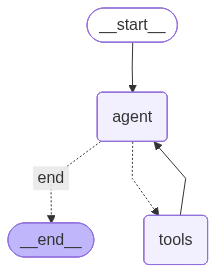

In [58]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage

query = 'What currency is in Billy Giles\' birthplace?'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

What currency is in Billy Giles' birthplace?
================================== Ai Message ==================================

I need to find out where Billy Giles was born. Once I have that information, I can provide you with the currency used in that place. Let's start by searching for Billy Giles' birthplace.
Tool Calls:
  duckduckgo_search (call_EUm3jlig5LchPL8stV3Jus8c)
 Call ID: call_EUm3jlig5LchPL8stV3Jus8c
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_search

Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street, in loyalist east Belfast. His father Sam, worked as a plater in the nearby Harland & Wolff shipyard, and his mother, Lily was a housewife. Mar 26, 2024 · Billy Giles was born William Alexander Ellis Giles in Belfast, Nort

In [19]:
from langchain_core.messages import HumanMessage

query = 'What currency is in Billy Giles\' birthplace? Find the currency and email it to nifelee@gmail.com'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

What currency is in Billy Giles' birthplace? Find the currency and email it to nifelee@gmail.com
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_r838kRY6erJgdNnMPfmhRulG)
 Call ID: call_r838kRY6erJgdNnMPfmhRulG
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_search

Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street, in loyalist east Belfast. His father Sam, worked as a plater in the nearby Harland & Wolff shipyard, and his mother, Lily was a housewife. Mar 26, 2024 · Billy Giles was born William Alexander Ellis Giles in Belfast, Northern Ireland on 3 September 1957, and grew up in Island Street, in loyalist east Belfast. His father Sam, worked as a plater in the near

In [49]:
from langchain_core.messages import HumanMessage

"""https://arxiv.org/abs/1706.03762"""

query = 'Attention is All You Need 논문 요약해서 nifelee@gmail.com 메일로 발송해줘.'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Attention is All You Need 논문 요약해서 nifelee@gmail.com 메일로 발송해줘.
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_ZeO20cA1Ezo3if36gZ074GzK)
 Call ID: call_ZeO20cA1Ezo3if36gZ074GzK
  Args:
    query: Attention is All You Need


HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=Attention+is+All+You+Need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)

In [60]:
from langchain_core.messages import HumanMessage

query = '15억인 집의 종합부동산세는 얼마인가요?'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

15억인 집의 종합부동산세는 얼마인가요?
================================== Ai Message ==================================
Tool Calls:
  estate_tax_retriever (call_t0UKIxBcAUahUrqJUzoptHoH)
 Call ID: call_t0UKIxBcAUahUrqJUzoptHoH
  Args:
    query: 15억 종합부동산세
================================= Tool Message =================================
Name: estate_tax_retriever

제15조(세부담의 상환)
③ 종합부동산세의 납세의무자가 종합부동산세 대상으로 토지에 대하여 해당 연도에 납부하여야 할 재산세(상대토지의 경우 재산세의 납세의무자가 종합부동산세대상인 해당 토지에 대하여 납부하여야 할 재산세액상당액을 말한다)와 토지의 종합부동산세액당액의 합계액이 이 중에서 “종합부동산세대상인 토지에 대한 재산세액상당액”이란 반대로 대등형량으로 정하는 바에 따라 계산한 세액이 해당 납세의무자가 직접적으로 해당 토지에 부과된 종합부동산세대상인 토지에 대한 재산세액상당액으로 대등형량으로 정하는 바에 따라 계산한 세액의 100분의 150초과하는 경우에는 그 과세하는 세액에 대해서는 제141조 제3항에 불구하고 이를 인정하는 것으로 본다. <개정 2005. 12. 31., 2008. 12. 26., 2020. 12. 29.>
➄ 종합부동산세의 납세의무자가 별론한산지세대상인 토지에 대하여 해당 연도에 납부하여야 할 재산세액상당액(신탁토지의 경우 재산세의 납세의무자가 별론한산지세대상인 해당 토지에 납부하여야 할 재산세액상당액의 합계액에 있어서 “별론한산지세대상인 토지에 대한 총세액상당액”이라 한다)으

# tools_condition

- should_continue 과 동일하게 내장 함수로 대체 가능

In [77]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition
)
graph_builder.add_edge('tools', 'agent')

In [62]:
graph = graph_builder.compile()

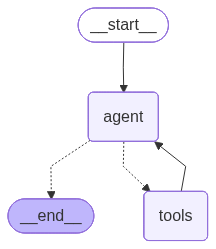

In [63]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))